# Introduction

This compares the distribution

In [ ]:
import pandas as pd 
import caliperpy
import os
import matplotlib.pyplot as plt
import numpy as np

def read_mtx(filename, dk):
    # Reads a matrix
    # dk = caliperpy.TransCAD.connect()
    out_dict = {}
    try:
        mtx = dk.OpenMatrix(filename, "True")
        cores = dk.GetMatrixCoreNames(mtx)
        for c in cores: # type: ignore
            m1 = dk.CreateMatrixCurrency(mtx, c, None, None, None)
            out_dict[c] = np.nan_to_num(np.array(dk.GetMatrixValues(m1, None, None), dtype=np.float32))
    except Exception as e:
        print(e) # type: ignore
    # finally:
        # dk.Close()
        # caliperpy.TransCAD.disconnect()
    return out_dict

def read_length_mtx(filename, dk):
    # Reads a matrix
    # dk = caliperpy.TransCAD.connect()
    out_dict = {}
    try:
        mtx = dk.OpenMatrix(filename, "True")
        # cores = dk.GetMatrixCoreNames(mtx)
        # for c in cores: # type: ignore
        #     m1 = dk.CreateMatrixCurrency(mtx, c, None, None, None)
        #     out_dict[c] = np.nan_to_num(np.array(dk.GetMatrixValues(m1, None, None), dtype=np.float32))
        m1 = dk.CreateMatrixCurrency(mtx, "Length (Skim)", None, None, None)    
        out = np.nan_to_num(np.array(dk.GetMatrixValues(m1, None, None), dtype=np.float32))
    except Exception as e:
        print(e) # type: ignore
    # finally:
        # dk.Close()
        # caliperpy.TransCAD.disconnect()
    return out

SCENARIO_BASE_FOLDER = r'C:\models\Reno_TDM\scenarios'
SCENARIO_CONTROL = 'base_2022'
SCENARIO_CHANGE = 'base_2022_resnets'
PERIODS = ['AM', 'MD', 'PM', 'NT']
PURPOSES = ['W_HBW', 'W_HBO', 'N_HBSCH', 'N_HBSHP', 'N_HBSR', 'N_HBO']
# PURPOSES = ['N_HBSHP', 'N_HBSR', 'N_HBO']

FILE_SUFFIX = "base"

purp_list = {
    'W_HBW': ['v0', 'ilvi', 'ilvs', 'ihvi', 'ihvs'],
    'W_HBO': ['v0', 'vi', 'vs'],
    'N_HBSCH': ['v0', 'vi', 'vs'],
    'N_HBSHP': ['v0', 'vi', 'vs'],
    'N_HBSR': ['v0', 'vi', 'vs'],
    'N_HBO': ['v0', 'vi', 'vs']
}

dk = caliperpy.TransCAD.connect()

base_totals = {}
chng_totals = {}
skim = {}

for purp in purp_list.keys():
    print(f"Working on purpose {purp}")
    for per in PERIODS:
        input = read_mtx(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CONTROL, 'output', 'resident', 'trip_matrices', f'pa_per_trips_{purp}_{per}.mtx'), dk)
        for vs in purp_list[purp]:
            if not (purp, per) in base_totals:
                base_totals[(purp, per)] = input[f'dc_{vs}']
            else:
                base_totals[(purp, per)] += input[f'dc_{vs}']

        input = read_mtx(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CHANGE, 'output', 'resident', 'trip_matrices', f'pa_per_trips_{purp}_{per}.mtx'), dk)
        for vs in purp_list[purp]:
            if not (purp, per) in chng_totals:
                chng_totals[(purp, per)] = input[f'dc_{vs}']
            else:
                chng_totals[(purp, per)] += input[f'dc_{vs}']

        if per in ['AM', 'PM']:
            skim[(purp, per)] = read_length_mtx(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CONTROL, 'output', 'skims', 'roadway', f'avg_skim_{per}_{purp[:4]}_sov.mtx'), dk)
        else:
            skim[(purp, per)] = read_length_mtx(os.path.join(SCENARIO_BASE_FOLDER, SCENARIO_CONTROL, 'output', 'skims', 'roadway', f'avg_skim_{per}_All_All_sov.mtx'), dk)
         

caliperpy.TransCAD.disconnect()

# mc_sov
# mc_hov2
# mc_hov3
# mc_auto_pay
# mc_w_lb
# mc_w_eb
# mc_pnr_lb
# mc_pnr_eb
# mc_knr_lb
# mc_knr_eb


Connecting to TransCAD...


In [ ]:
tlf = {}
atlf = []

for purp in purp_list.keys():
    for per in PERIODS:
        df1 = pd.DataFrame({'base_trips': base_totals[(purp, per)].flatten('C'), 'adist': skim[(purp, per)].flatten('C')})
        df1['dist'] = df1['adist'].round(1)

        df2 = pd.DataFrame({'chng_trips': chng_totals[(purp, per)].flatten('C'), 'adist': skim[(purp, per)].flatten('C')})
        df2['dist'] = df2['adist'].round(1)

        df = df1.groupby('dist').agg(base_trips = ('base_trips', 'sum')).join(df2.groupby('dist').agg(chng_trips = ('chng_trips', 'sum')), how = 'outer').rename(columns = {'base_trips': f'base_{purp}_{per}', 'chng_trips': f'chng_{purp}_{per}'})
        tlf[(purp, per)] = df

        atlf.append({'purpose': purp, 'period': per, 'base_atlf': np.average(df1['dist'], weights = df1['base_trips']), 'change_atlf': np.average(df2['dist'], weights = df2['chng_trips'])})


In [ ]:
pd.DataFrame(atlf).to_excel(rf'C:\models\Reno_TDM\scenarios\base_2022_with_resnets\output\_summaries\Resnet_compare\avg_tlf_dl{FILE_SUFFIX}.xlsx')

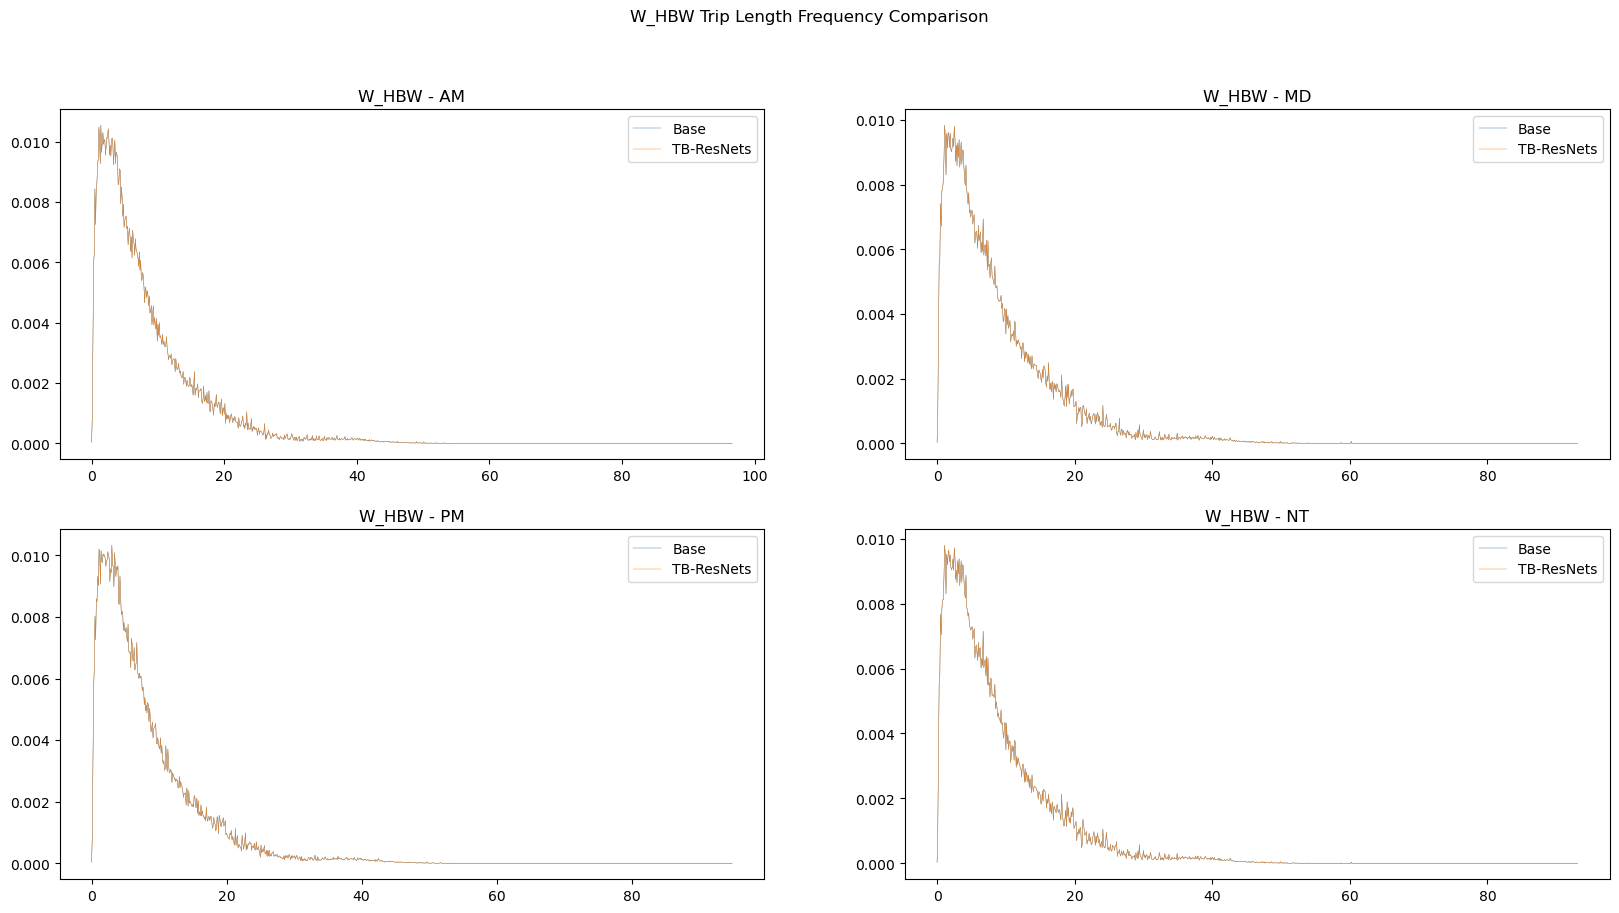

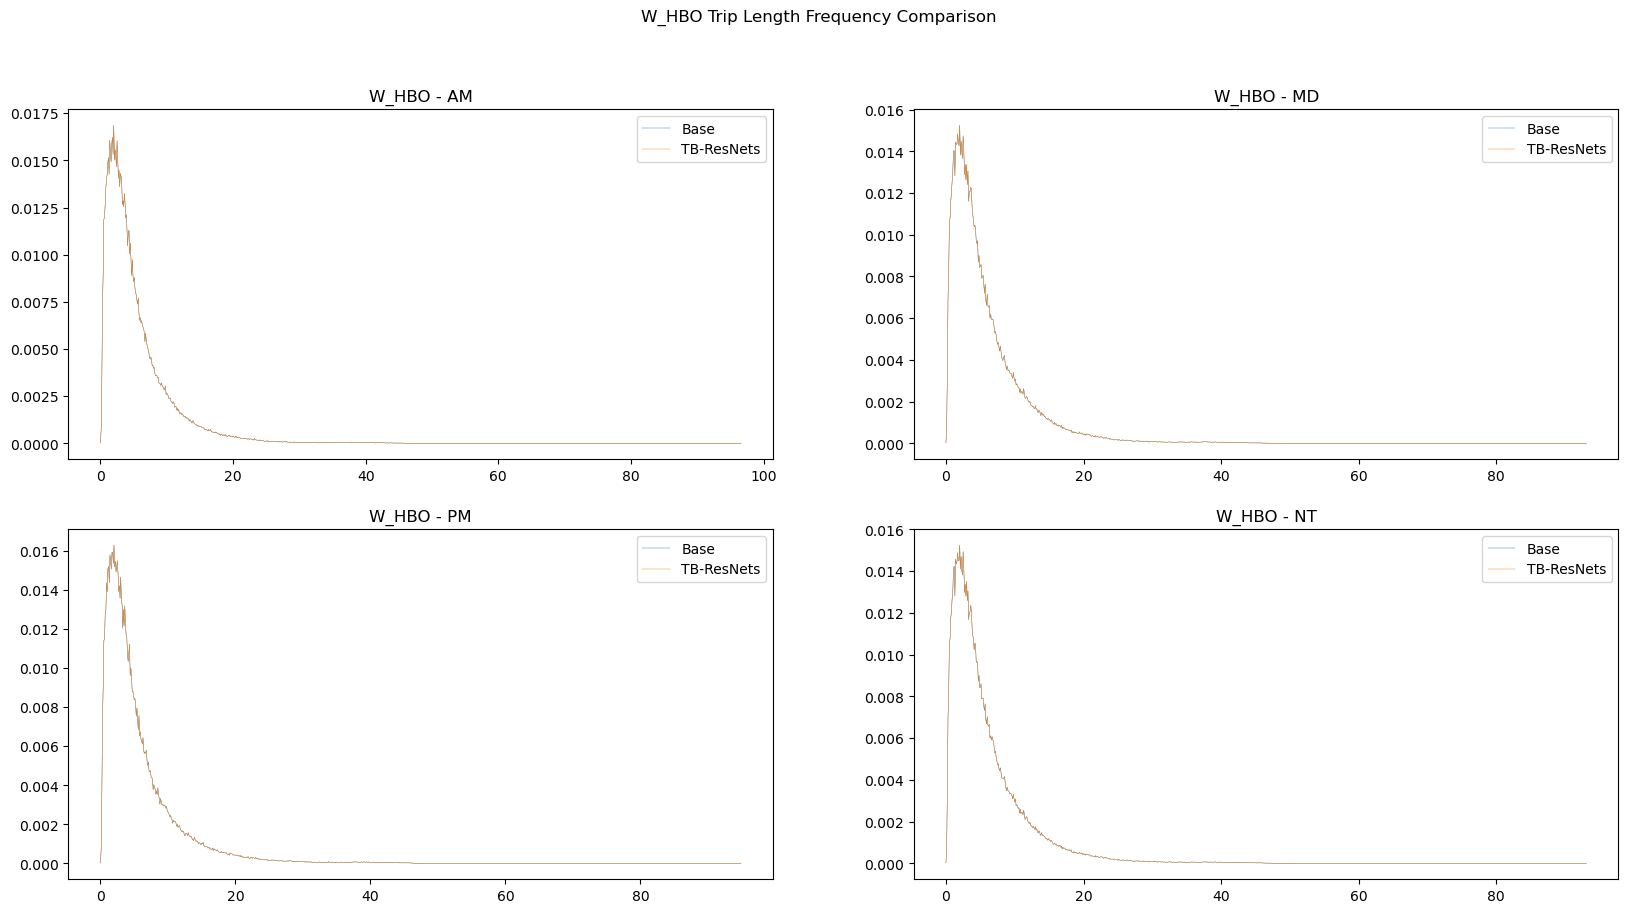

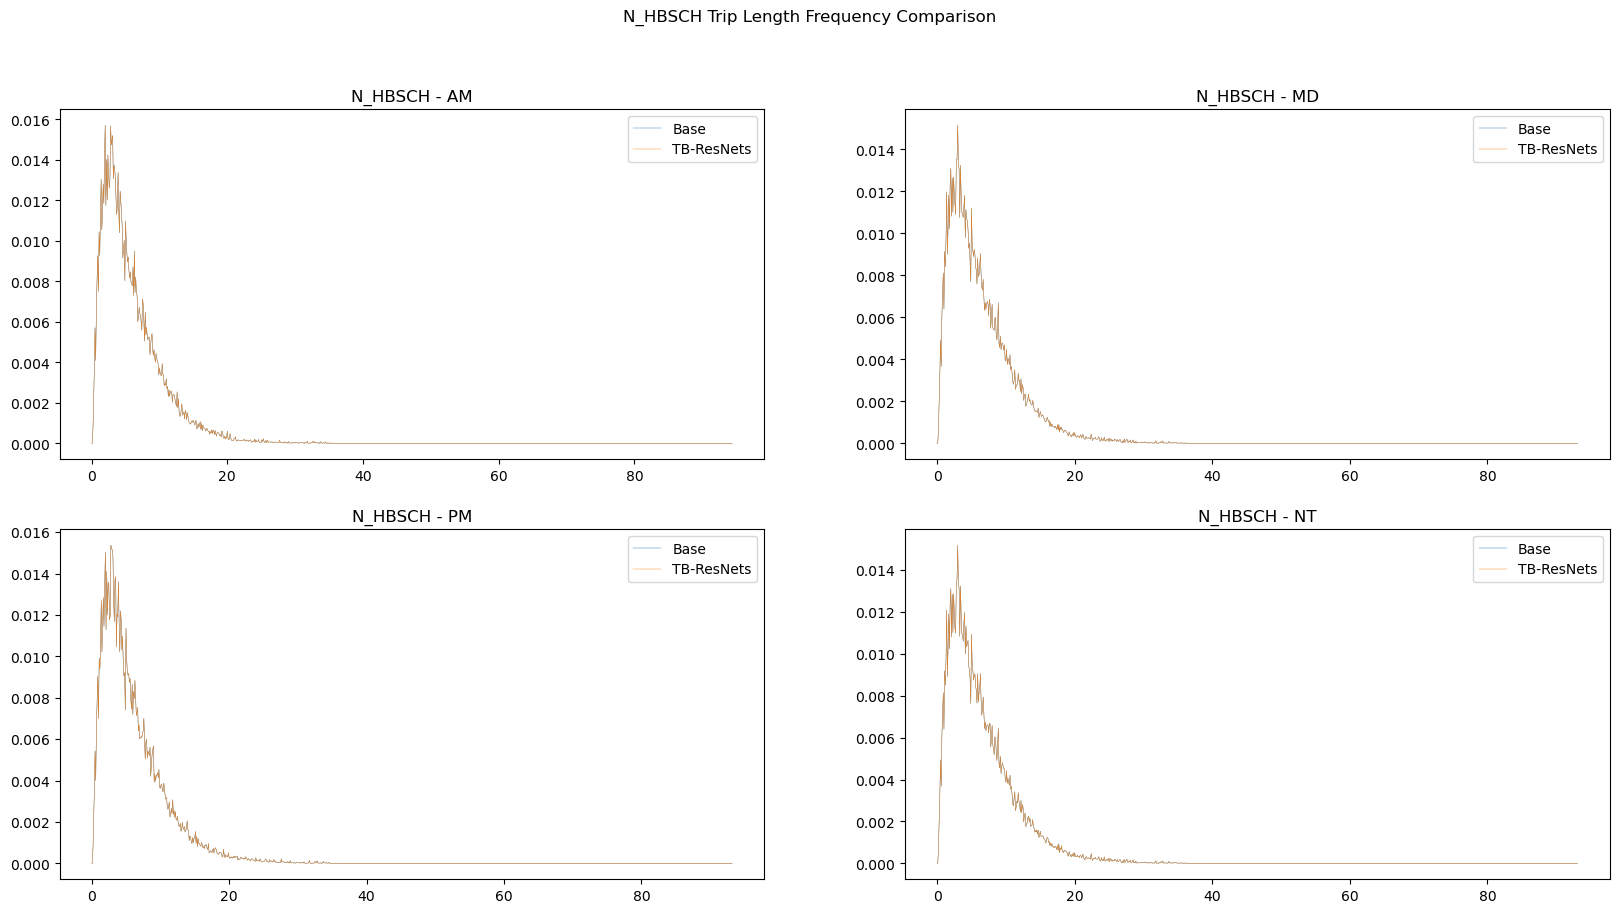

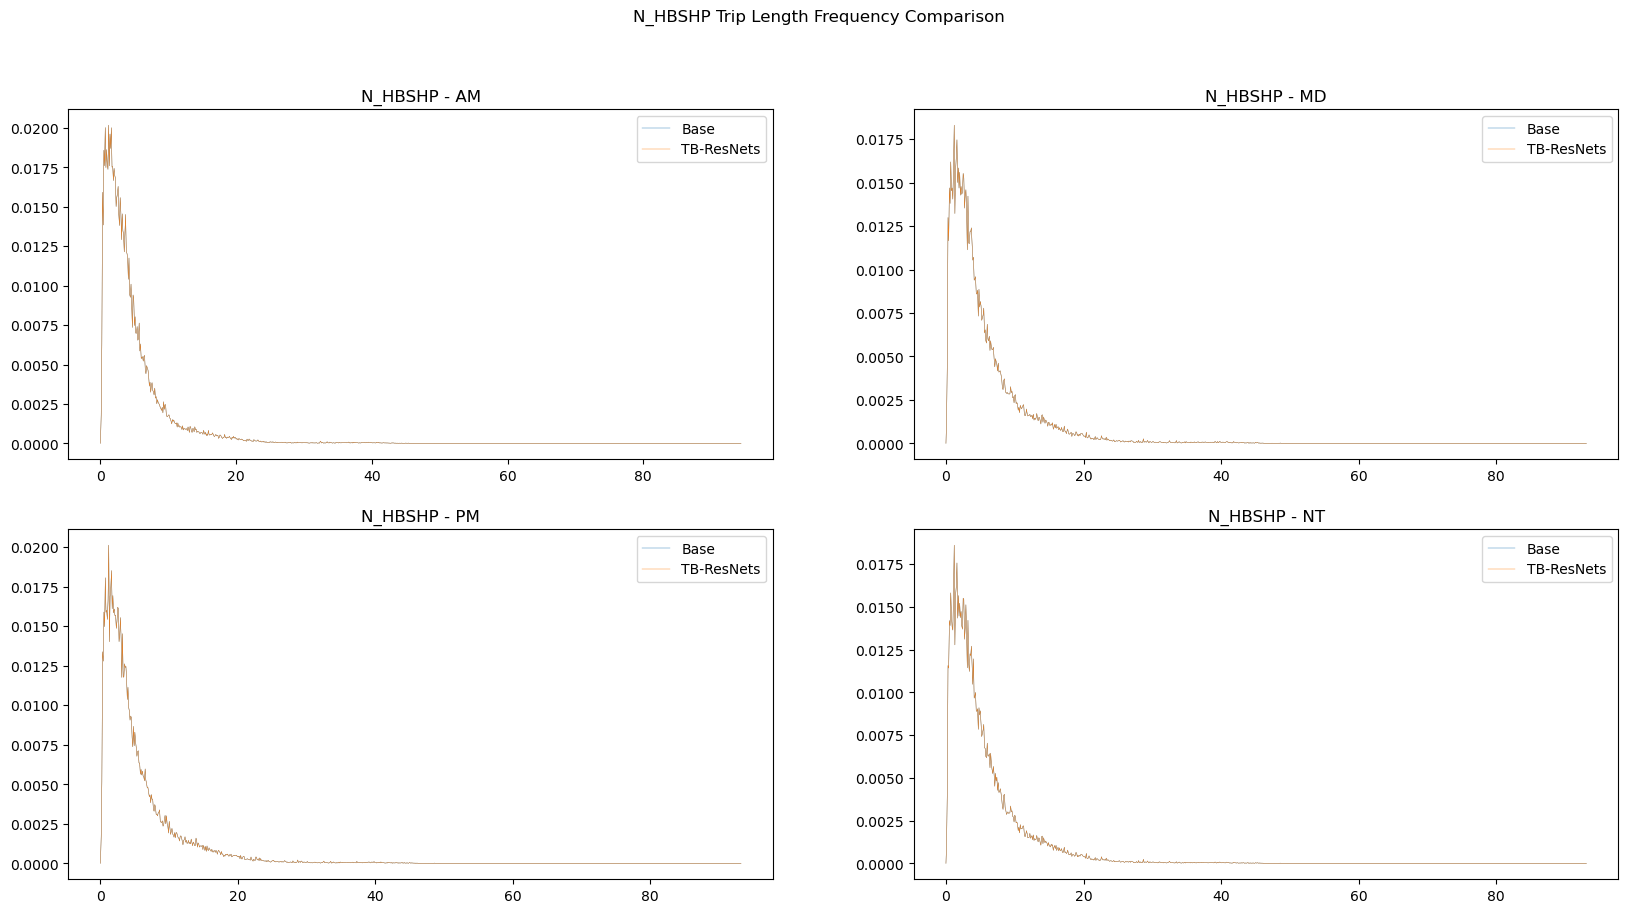

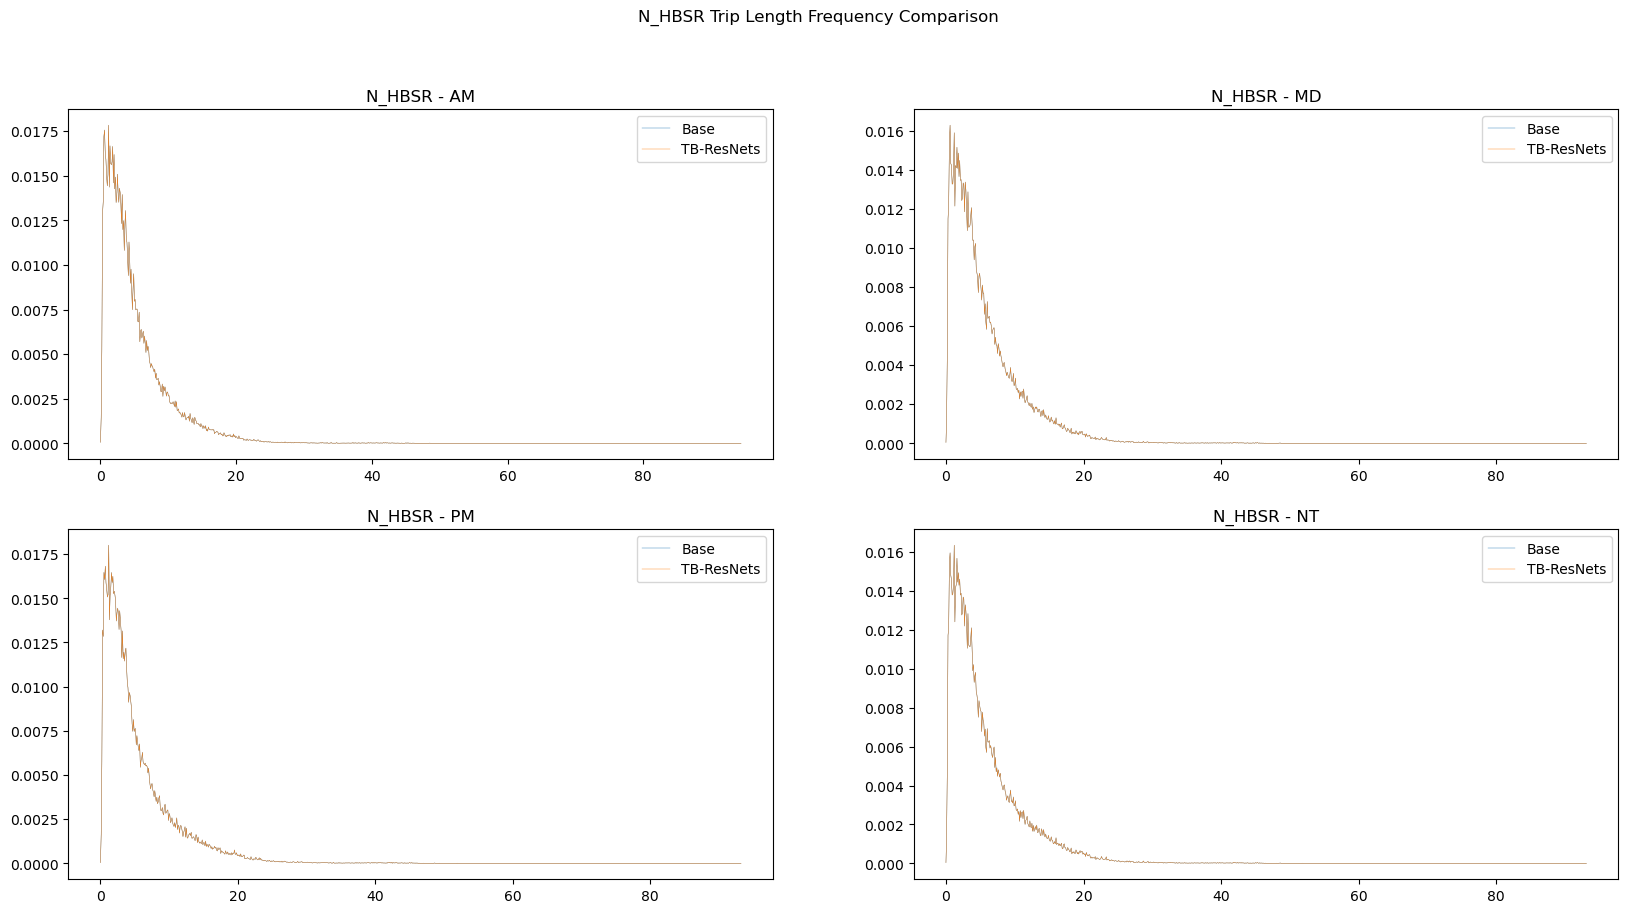

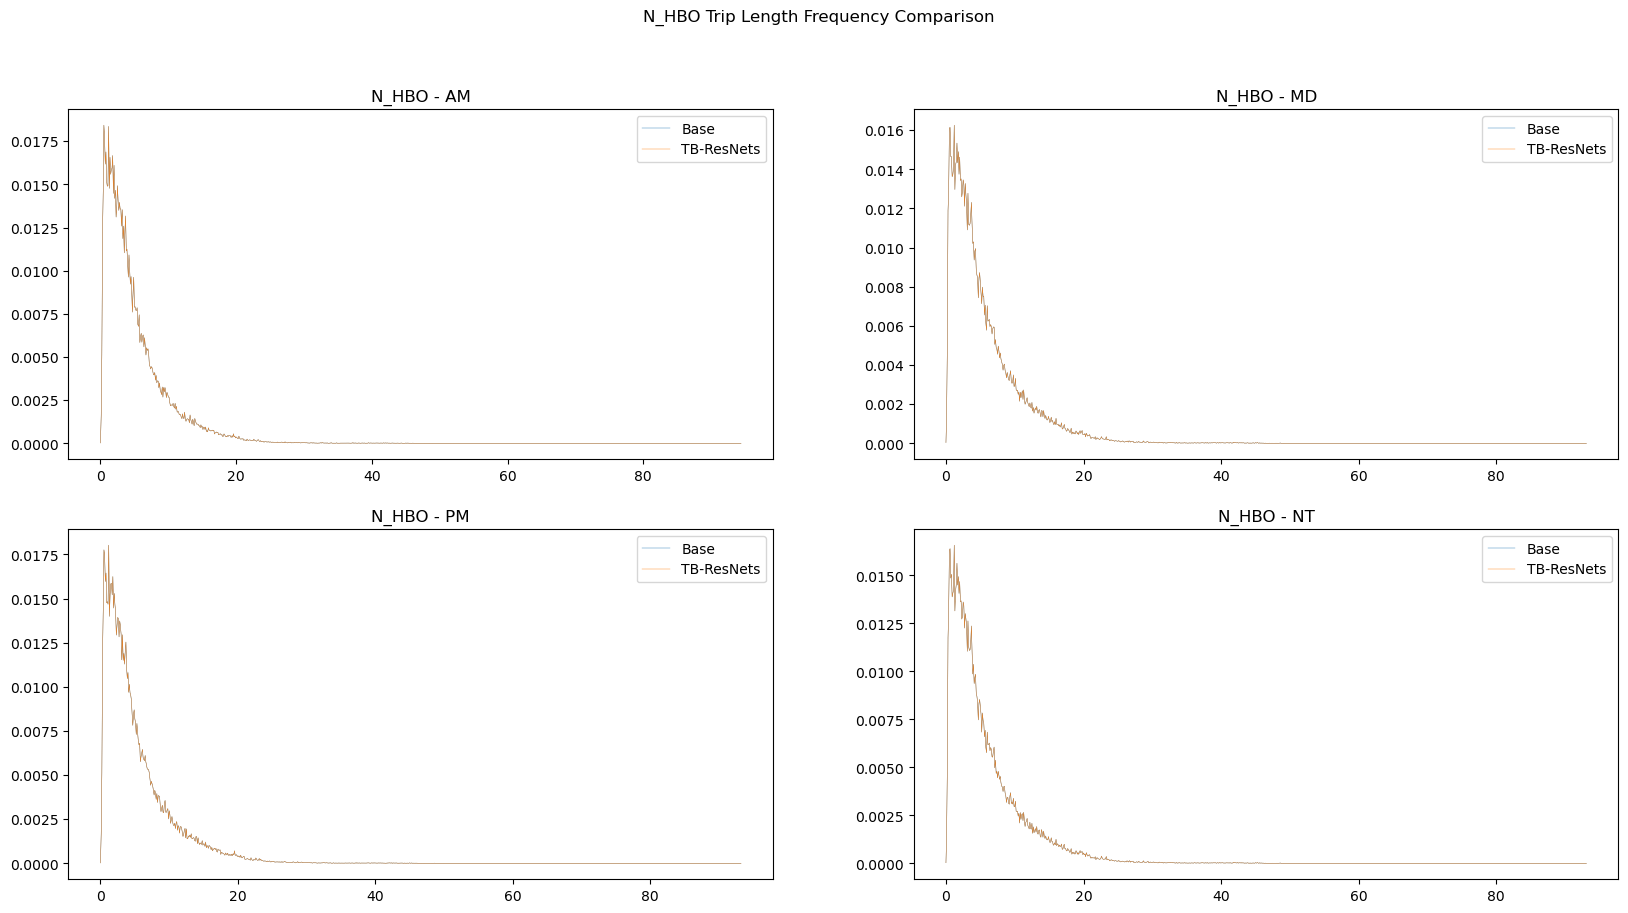

In [ ]:
for purp in purp_list.keys():
    fig, ax = plt.subplots(2, 2, figsize=(20, 10))
    plot_idx = 220
    cnt = 1
    for per in PERIODS:
        plotdf = tlf[(purp, per)]
        plotdf['pct_base'] = plotdf[plotdf.columns[0]] / plotdf[plotdf.columns[0]].sum()
        plotdf['pct_chng'] = plotdf[plotdf.columns[1]] / plotdf[plotdf.columns[1]].sum()
        ax = plt.subplot(plot_idx + cnt)
        ax.plot(plotdf.index, plotdf['pct_base'], label = 'Base', linewidth = 0.3)
        ax.plot(plotdf.index, plotdf['pct_base'], label = 'TB-ResNets', linewidth = 0.3)
        plt.legend(loc = 'upper right')
        plt.title(f"{purp} - {per}")
        cnt += 1
    plt.suptitle(f"{purp} Trip Length Frequency Comparison")
    plt.show()




In [ ]:
pd.concat(tlf, axis = 1).to_excel(rf'C:\models\Reno_TDM\src\resnet_check_notebooks\dist_ck_dl{FILE_SUFFIX}.xlsx') #.to_clipboard()

## Overall Destination Compare

In [ ]:
diff = {}
base = {}
chng = {}
for k in chng_totals.keys():
    if not k[1] in diff.keys():
        diff[k[1]] = chng_totals[k] - base_totals[k]
        base[k[1]] = base_totals[k]
        chng[k[1]] = chng_totals[k]
    else:
        diff[k[1]] += chng_totals[k] - base_totals[k]
        base[k[1]] += base_totals[k]
        chng[k[1]] += chng_totals[k]

In [ ]:
dest_change = pd.DataFrame({'base_am': base['AM'].sum(0), 'chng_am': chng['AM'].sum(0), 
                            'base_md': base['MD'].sum(0), 'chng_md': chng['MD'].sum(0), 
                            'base_pm': base['PM'].sum(0), 'chng_pm': chng['PM'].sum(0), 
                            'base_nt': base['NT'].sum(0), 'chng_nt': chng['NT'].sum(0)})


dest_change.to_excel(rf'C:\models\Reno_TDM\src\resnet_check_notebooks\dest_chg_dl{FILE_SUFFIX}.xlsx')

In [ ]:
chng_totals

{('W_HBW',
  'AM'): array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.00032253, 0.00123273, 0.01008974, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ]], shape=(1176, 1176), dtype=float32),
 ('W_HBW',
  'MD'): array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
         0.        ],
        [0.00142917, 0.00459372, 0.03940959, ..., 0.        , 0.        ,
         0.        ],
        ...,
        [0.        , 0.        , 0.